from IPython.display import Markdown, display

display(Markdown(r"""
# Experiment: The Birthday Paradox

## Context

People are drawn one by one at random (365 possible days, birthdays assumed
equally likely, leap years ignored). We're interested in the rank `k` of the
**first** person whose birthday matches someone already drawn.

## The two functions

### `Q(n)` — no collision among the first n

`Q(n)` is the probability that the first `n` people all have different
birthdays:

- `Q(k-1)`: the first `k-1` people all have distinct birthdays.
- `(k-1)/365`: given that, person `k` has `(k-1)` chances out of 365 of
  landing on a birthday already taken.

So `f` is a **probability distribution** over the rank of the first
collision (the sum of `f(k)` over all `k` equals 1).

## What the plot shows

Plotting `f(k)` for `k` from 2 to 50 gives a bell-shaped curve:

- it rises at first, since the more people have already been drawn, the more
  days are "occupied" and the more likely a collision becomes;
- it peaks around **k ≈ 20**, the most likely rank for the very first
  collision;
- then it decreases: beyond a certain rank, it becomes rare that no
  collision has happened yet, so the probability that *this specific*
  person is the one to trigger it goes down.

## Distinguishing from the "classic" version of the paradox

The classic statement ("how many people are needed to have more than a 50%
chance of a collision?") gives **k = 23**, using the **cumulative**
probability `1 - Q(k)`.

Here, `f(k)` answers a different, more precise question: "what is the most
likely rank for the collision to happen **exactly at that point**?" — and
the answer is **k = 20**.
"""))

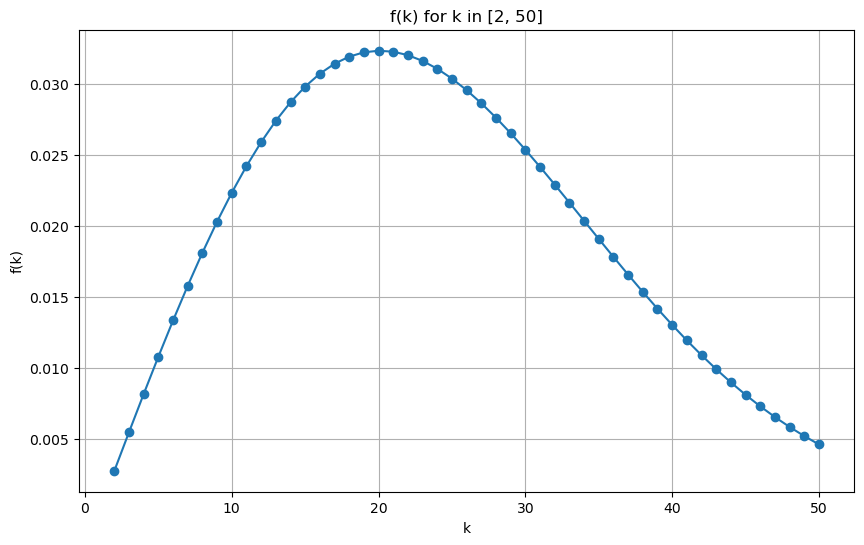

In [1]:
import matplotlib.pyplot as plt


def Q(n):
    """Probability that the first n people all have different birthdays."""
    q = 1.0
    for i in range(n):
        q *= (365 - i) / 365
    return q


def f(k):
    """Probability that the k-th person is the FIRST to cause a collision
    (i.e. the first k-1 people all have distinct birthdays, and the k-th
    person shares a birthday with one of them)."""
    return Q(k - 1) * (k - 1) / 365


# Values of k between 2 and 50
x = range(2, 51)

# Values of f(k)
y = [f(k) for k in x]

# Plot
plt.figure(figsize=(10, 6))
plt.plot(x, y, marker='o')
plt.xlabel("k")
plt.ylabel("f(k)")
plt.title("f(k) for k in [2, 50]")
plt.grid(True)
plt.show()